In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import os
import pandas as pd
import numpy as np
import librosa
import random
import cv2
from matplotlib import cm

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline

from transformers import Resampler, MelSpectrogramTransformer, SpectrogramPadder, FlattenTransformer, FeatureExtractor, WaveletDenoiser, NoiseAdder, Normalizer

from config import TEST_SIZE, SEED, SAMPLING_RATE, N_MELS, N_FFT

In [2]:
def plot_mel_spectrogram(S_dB, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    librosa.display.specshow(S_dB, sr=SAMPLING_RATE, x_axis='time', y_axis='mel', ax=ax);

# Conformación del Dataset Final

In [3]:
df = pd.read_csv('./dataset/audios_ventanas/labels.csv')

In [4]:
df.head()

,filename,label
0,101_1b1_Al_sc_Meditron_win000.wav,normal
1,101_1b1_Al_sc_Meditron_win001.wav,normal
2,101_1b1_Al_sc_Meditron_win002.wav,normal
3,101_1b1_Al_sc_Meditron_win003.wav,normal
4,101_1b1_Al_sc_Meditron_win004.wav,normal


In [6]:
df.label.value_counts()

label
normal     2433
crackle    1410
wheeze      672
both        493
Name: count, dtype: int64

In [7]:
df['label'] = df['label'].map({'normal': 0, 'wheeze': 1, 'crackle': 1, 'both': 1})

In [8]:
df.label.value_counts()

label
1    2575
0    2433
Name: count, dtype: int64

# Armado del dataset

In [10]:
dataset = 'crudos'

os.makedirs(f'./dataset/ventanas_procesadas/{dataset}', exist_ok=True)

In [11]:
X = df['filename'].tolist()
y = df['label'].tolist()

X = [os.path.join('./dataset/audios_ventanas/', path) for path in X]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y
)

In [12]:
pipeline_temp = Pipeline([
    ('resampler', Resampler()),
    ('melspec', MelSpectrogramTransformer(n_fft=N_FFT, n_mels=N_MELS, hop_length=128))
])

X_proc = pipeline_temp.fit_transform(X_train)

c:\Users\nazar\Clasificador-Respiracion\venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=1
  warnings.warn(


In [13]:
import warnings

short_indices = []

for i, x in enumerate(X_train):
    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter("always")
        _ = pipeline_temp.transform([x])
        if any("n_fft" in str(warn.message) for warn in w):
            short_indices.append(i)

print("Audios demasiado cortos:", short_indices)

Audios demasiado cortos: [13, 498, 751, 1483, 1498, 1854, 1982, 2027, 2385, 2746, 2770, 2798, 2949]


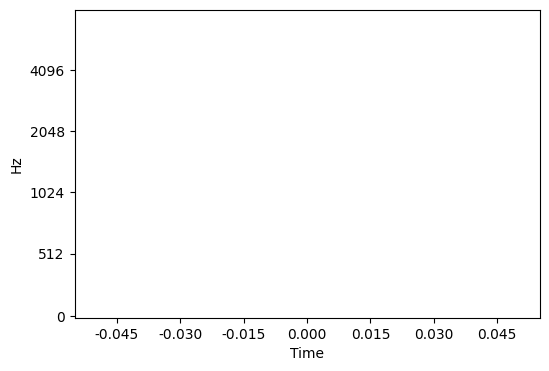

In [24]:
plot_mel_spectrogram(X_proc[13].reshape(128, -1))

In [25]:
for i in short_indices:
    print(f'Index: {i}, Label: {y_train[i]}')

Index: 13, Label: 0
Index: 498, Label: 0
Index: 751, Label: 0
Index: 1483, Label: 0
Index: 1498, Label: 0
Index: 1854, Label: 0
Index: 1982, Label: 0
Index: 2027, Label: 0
Index: 2385, Label: 0
Index: 2746, Label: 0
Index: 2770, Label: 0
Index: 2798, Label: 0
Index: 2949, Label: 0


In [26]:
for index in sorted(short_indices, reverse=True):
    del X_train[index]
    del y_train[index]

lo mismo en test

In [27]:
X_proc = pipeline_temp.fit_transform(X_test)

short_indices = []
for i, x in enumerate(X_test):
    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter("always")
        _ = pipeline_temp.transform([x])
        if any("n_fft" in str(warn.message) for warn in w):
            short_indices.append(i)
print("Audios demasiado cortos en test:", short_indices)

c:\Users\nazar\Clasificador-Respiracion\venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=1
  warnings.warn(


Audios demasiado cortos en test: [233, 366, 986]


In [28]:
# check labels for short audios
for i in short_indices:
    print(f'Index: {i}, Label: {y_test[i]}')

Index: 233, Label: 0
Index: 366, Label: 0
Index: 986, Label: 0


In [29]:
for index in sorted(short_indices, reverse=True):
    del X_test[index]
    del y_test[index]

In [30]:
X_proc[0].shape

(128, 501)

#### Mel espectrograma

In [31]:
pipeline_melspec = Pipeline([
    ('resampler', Resampler()),
    ('melspec', MelSpectrogramTransformer(n_fft=N_FFT, n_mels=N_MELS, hop_length=128)),
    ('spectrogram_padder', SpectrogramPadder(max_length=501)),
    ('flatten', FlattenTransformer())
])

In [32]:
X_train_melspecs = pipeline_melspec.fit_transform(X_train)

In [33]:
X_test_melspecs = pipeline_melspec.transform(X_test)

c:\Users\nazar\Clasificador-Respiracion\venv\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [34]:
print(X_train_melspecs.shape, X_test_melspecs.shape)

(3993, 64128) (999, 64128)


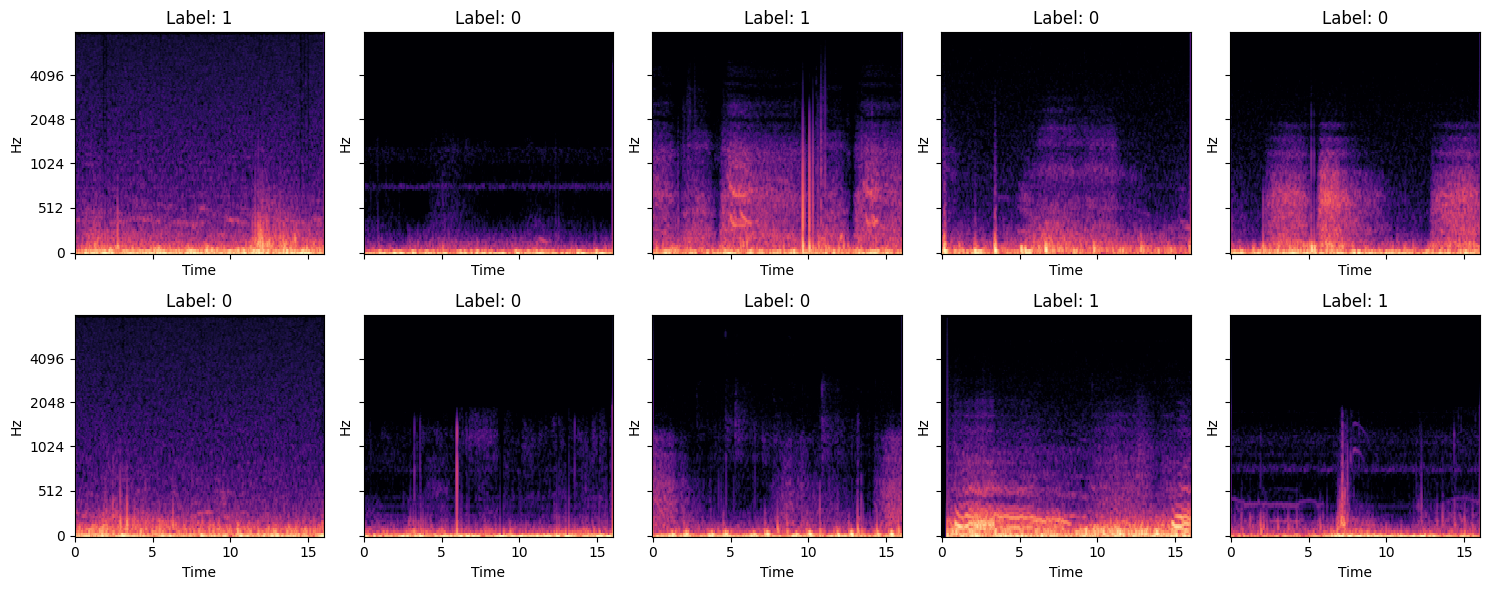

In [36]:
fig, axs = plt.subplots(2, 5, figsize=(15,6), sharey=True, sharex=True)
for i in range(10):
    ax = axs[i//5, i%5]
    img = librosa.display.specshow(X_train_melspecs[i].reshape(N_MELS, 501), sr=SAMPLING_RATE, x_axis='time', y_axis='mel', n_fft=1024, ax=ax, cmap='magma')
    ax.set_title(f'Label: {y_train[i]}')
plt.tight_layout();

In [38]:
np.savez_compressed(
    f'./dataset/ventanas_procesadas/{dataset}/train_melspectrogram.npz',
    X=X_train_melspecs,
    y=y_train
)

np.savez_compressed(
    f'./dataset/ventanas_procesadas/{dataset}/test_melspectrogram.npz',
    X=X_test_melspecs,
    y=y_test
)

#### Features

In [39]:
pipeline_feature_extraction = Pipeline([
    ('resampler', Resampler()),
    ('feature_extractor', FeatureExtractor(n_fft=N_FFT))
])

In [40]:
X_train_features = pipeline_feature_extraction.fit_transform(X_train)

c:\Users\nazar\Clasificador-Respiracion\venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1280
  warnings.warn(


In [41]:
X_test_features = pipeline_feature_extraction.transform(X_test)

In [43]:
np.savez_compressed(
    f'./dataset/ventanas_procesadas/{dataset}/train_features.npz',
    X=X_train_features,
    y=y_train
)

np.savez_compressed(
    f'./dataset/ventanas_procesadas/{dataset}/test_features.npz',
    X=X_test_features,
    y=y_test
)

## Imagenes

In [47]:
def plot_mel_spectrogram(y, sr=SAMPLING_RATE, ax=None, cmap='magma'):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, n_fft=N_FFT, hop_length=128)
    S_dB = librosa.power_to_db(S, ref=np.max)
    librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel', ax=ax, cmap=cmap);

def normalize_spec(spec):
    spec_min, spec_max = spec.min(), spec.max()
    spec = (spec - spec_min) / (spec_max - spec_min + 1e-6)
    spec = (spec * 255).astype(np.uint8)
    return spec

def spec_to_rgb(spec):
    spec = normalize_spec(spec)
    spec_color = cm.magma(spec / 255.0)[:, :, :3]  # RGB float 0–1
    return (spec_color * 255).astype(np.uint8)

def save_mel_images(X, y, split_name, dataset):
    output_dir = f'./dataset/ventanas_procesadas/{dataset}/{split_name}'
    os.makedirs(output_dir, exist_ok=True)

    filenames = []
    for i, spec in enumerate(X):
        spec_rgb = spec_to_rgb(np.flipud(spec))
        # cv2 usa BGR → convertimos para guardar bien los colores
        cv2.imwrite(os.path.join(output_dir, f"{i}.png"), cv2.cvtColor(spec_rgb, cv2.COLOR_RGB2BGR))
        filenames.append(f"{i}.png")

    pd.DataFrame({
        'filename': filenames,
        'label': y
    }).to_csv(f'{output_dir}/labels.csv', index=False)

Guardar imagenes

Para las NN necesito un conjunto de validacion

In [48]:
X_train_melspecs, X_val_melspecs, y_train, y_val = train_test_split(
    X_train_melspecs, y_train, test_size=0.2, random_state=SEED, stratify=y_train
)

In [49]:
save_mel_images(X_train_melspecs.reshape(-1, N_MELS, 501), y_train, 'imgs/train', dataset)
save_mel_images(X_val_melspecs.reshape(-1, N_MELS, 501), y_val, 'imgs/val', dataset)
save_mel_images(X_test_melspecs.reshape(-1, N_MELS, 501), y_test, 'imgs/test', dataset)